# Navier-Stokes Equation

The Navier-Stokes equation is a non-linear PDE able to describe mass and momentum balance of fluid flow problems, commonly written as

$$
\underbrace{\partial_t \rho + \partial_{\alpha}\rho u_{\alpha} = 0}_{\textrm{Mass Balance Equation}},
$$

$$
\underbrace{\partial_t \rho u_{\alpha} + \partial_{\beta}\left(\rho u_{\alpha}\rho u_{\beta}\right) = \partial_{\beta}\left( -p \delta_{\alpha\beta} + \mu\left(\partial_{\alpha}u_{\beta}+\partial_{\beta}u_{\alpha}\right) \right) + \rho g_{\alpha}}_{\textrm{Momentum Balance Equation}} ,
$$(ns-eq-lb)

where $\rho$ is the fluid density, $u_{\alpha}$ is the $\alpha$-th component of the velocity vector field, $p$ is the pressure field, $\delta_{\alpha\beta}$ is the Kronecker delta, $\mu$ is the dynamic viscosity (a constitutive parameter controlling the intensity of viscous diffusion), and $g_{\alpha}$ is the $\alpha$-th component of the external body acceleration (e.g., gravity).

## Numerical Discretization: Lattice Boltzmann Equation

Describing the problem through the BGK lattice Boltzmann equation:

$$
\underbrace{f_{i}\left(x_{\alpha}+ c_{i,\alpha} \Delta t, t+\Delta t\right)- f_{i}(x_{\alpha}, t)= -\left( \frac{ f_{i} - f_{i}^{eq} }{ \tau} \right) }_{\textrm{1st order space-time discretization}}.
$$(LB-ns-1st-Eq)

$$
\underbrace{\hat{f}_{i}\left(x_{\alpha}+ c_{i,\alpha} \Delta t, t+\Delta t\right)- \hat{f}_{i}(x_{\alpha}, t)= -\left( \frac{ \hat{f}_{i} - \hat{f}_{i}^{eq} }{ \tau } \right) + \left(1-\frac{1}{2\tau}F_{i} \right) }_{\textrm{2nd order space-time discretization}}.
$$(LB-ns-2nd-Eq)

The equilibrium distribution function is defined by

$$
f^{eq}_{i} = w_{i}\rho\left( 1 + \frac{c_{i,\alpha} u_{\alpha}}{c_{s}^{2}} + \frac{  u_{\alpha}u_{\beta}  \left( c_{i,\alpha}c_{i,\beta} - c_{s}^{2}\delta_{\alpha\beta} \right)}{2c_{s}^{4}}  \right).
$$

### Lattice Direction Moments: D2Q9 Velocity-Space Discetization

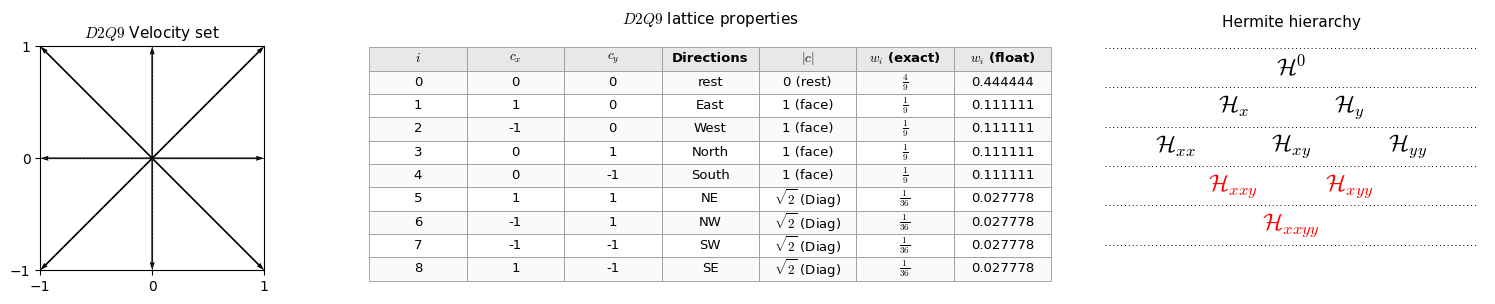

In [3]:
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display, Math
from __future__ import division
from sympy import *
import numpy as np
from sympy import S, collect, expand, factor, Wild
from sympy import fraction, Rational, Symbol
from sympy import symbols, sqrt, Rational
import sympy as sp
import matplotlib    
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
matplotlib.rcParams['mathtext.fontset'] = 'cm'

#-------------------------------------------------Símbolos----------------------------------------------
omega, rho, ux, uy = symbols('omega, rho, u_{x}, u_{y}')
wi, cx, cy, cs = symbols('w_{i} c_{x} c_{y} c_{s}')
#-------------------------------------------------Funções----------------------------------------------
feq = Function('feq')(wi, cx, cy)
#----------------------------------------------Lattice-D2Q9---Variáveis----------------------------------------------
w0=Rational(16,36);w1=Rational(4,36);w2=Rational(1,36)
wi=np.array([w0,w1,w1,w1,w1,w2,w2,w2,w2])
cx=np.array([0, 1,-1, 0, 0,1,-1,-1, 1])
cy=np.array([0, 0, 0, 1,-1,1, 1,-1,-1])
cs=sp.sqrt(Rational(1,3))
#-------------------------------------------------Calc.Func------------------------------------------------
feq = wi*rho*(1 + (cx*ux+cy*uy)/cs**2 + (cx*ux+cy*uy)**2/(2*cs**4) - (ux*ux+uy*uy)/(2*cs**2))

#===========================BUILD TABLE DATA=====================================================
w_vals  = [sp.nsimplify(w) for w in wi]
w_float = [float(sp.N(w))    for w in wi]
cx_vals = [int(v) for v in cx]
cy_vals = [int(v) for v in cy]
speed, direction = [], []
for i in range(9):
    c2 = cx_vals[i]**2 + cy_vals[i]**2
    if c2 == 0:
        speed.append('0 (rest)'); direction.append('rest')
    elif c2 == 1:
        speed.append('1 (face)')
        direction.append({(1,0):'East', (-1,0):'West',(0,1):'North', (0,-1):'South'}[(cx_vals[i], cy_vals[i])])
    else:
        speed.append(r'$\sqrt{2}$ (Diag)')
        direction.append({(1,1):'NE', (-1,1):'NW',(-1,-1):'SW', (1,-1):'SE'}[(cx_vals[i], cy_vals[i])])

headers = ['$i$', '$c_x$', '$c_y$', 'Directions', '$|c|$', '$w_i$ (exact)', '$w_i$ (float)']
cell_text = [[str(i), str(cx_vals[i]), str(cy_vals[i]),direction[i], speed[i],f'${sp.latex(w_vals[i])}$',f'{w_float[i]:.6f}'] for i in range(9)]
#==================FIGURE: LATTICE | TABLE | HERMITE HIERARCHY==============================================================
fig = plt.figure(figsize=(15.5, 2.8))
ax_lat  = fig.add_axes([0.03, 0.10, 0.20, 0.80])   # left
ax_tab  = fig.add_axes([0.27, 0.02, 0.44, 0.92])   # middle
ax_her  = fig.add_axes([0.74, 0.05, 0.25, 0.88])   # right
ax_tab.axis('off')
ax_her.axis('off')
ax_her.set_xlim(0, 1)
ax_her.set_ylim(0, 1)
#-----------------------------------------------------------------------
#  LEFT: quiver lattice (your original style)
#-----------------------------------------------------------------------
origin_x = np.zeros_like(cx)
origin_y = np.zeros_like(cy)
ax_lat.quiver(origin_x, origin_y, cx, cy,angles='xy', scale_units='xy', scale=1, color='black')
ax_lat.set_xlim(-1, 1); ax_lat.set_ylim(-1, 1)
ax_lat.axhline(0, color='black', linewidth=0.5)
ax_lat.axvline(0, color='black', linewidth=0.5)
ax_lat.grid(True, linestyle='--', linewidth=0.5)
ax_lat.set_title("$D2Q9$ Velocity set", fontsize=11)
ax_lat.set_xticks(np.arange(-1, 2, 1))
ax_lat.set_yticks(np.arange(-1, 2, 1))
ax_lat.set_aspect('equal')
#-----------------------------------------------------------------------
#  MIDDLE: properties table
#-----------------------------------------------------------------------
table = ax_tab.table(cellText=cell_text, colLabels=headers,loc='center', cellLoc='center', colLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.0, 1.4)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#999999'); cell.set_linewidth(0.6)
    if r == 0:
        cell.set_facecolor('#e8e8e8'); cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor('#fafafa' if r % 2 else 'white')
ax_tab.set_title("$D2Q9$ lattice properties", fontsize=11, pad=8)
#-----------------------------------------------------------------------
#  RIGHT: Hermite polynomial hierarchy (triangular, like the picture)
#-----------------------------------------------------------------------
ax_her.set_title("Hermite hierarchy", fontsize=11, pad=8)
# Levels (top -> bottom): each is a list of (x_fraction, label)
levels = [
    (0.88, [(0.50, r'$\mathcal{H}^{0}$', 'black')]),
    (0.72, [(0.35, r'$\mathcal{H}_{x}$', 'black'), (0.65, r'$\mathcal{H}_{y}$', 'black')]),
    (0.56, [(0.20, r'$\mathcal{H}_{xx}$', 'black'), (0.50, r'$\mathcal{H}_{xy}$', 'black'), (0.80, r'$\mathcal{H}_{yy}$', 'black')]),
    (0.40, [(0.35, r'$\mathcal{H}_{xxy}$', 'red'), (0.65, r'$\mathcal{H}_{xyy}$', 'red')]),
    (0.24, [(0.50, r'$\mathcal{H}_{xxyy}$', 'red')]),
]
# dotted horizontal separators (between levels, and below top/bottom)
sep_y = [0.96, 0.80, 0.64, 0.48, 0.32, 0.16]
for y in sep_y:
    ax_her.plot([0.02, 0.98], [y, y],color='black', linewidth=0.7,linestyle=(0, (1, 3)))     # fine dotted
# place labels (large, centered at each x)
for y, items in levels:
    for x, txt, col in items:
        ax_her.text(x, y, txt,ha='center', va='center',fontsize=17, color=col)
# panel label "(b)" at top
ax_her.text(0.50, 1.00, '',ha='center', va='bottom',fontsize=13, fontweight='bold',transform=ax_her.transAxes)

plt.show()

#### Raw Moments

In [40]:
a0=simplify(sum(feq))
ax=simplify(sum(feq*cx))
ay=simplify(sum(feq*cy))
axx=simplify(sum(feq*cx*cx))
axy=simplify(sum(feq*cx*cy))
ayy=simplify(sum(feq*cy*cy))
axxx=simplify(sum(feq*cx*cx*cx))
axxy=simplify(sum(feq*cx*cx*cy))
axyy=simplify(sum(feq*cx*cy*cy))
ayyy=simplify(sum(feq*cy*cy*cy))
display(Math(r"\begin{gathered}"
    r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Moment}} =" + sp.latex(a0)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}c_{i,x} }_{\textrm{x-First-Order Moment}} =" + sp.latex(ax)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}c_{i,y} }_{\textrm{y-First-Order Moment}} =" + sp.latex(ay)
    +r"\\[10pt]"
    +r"\underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x} }_{\textrm{xx-Second-Order Moment}} =" + sp.latex(axx)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,y} }_{\textrm{xy-Second-Order Moment}} =" + sp.latex(axy)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,y}c_{i,y} }_{\textrm{yy-Second-Order Moment}} =" + sp.latex(ayy)
    +r"\\[10pt]"
    +r"\underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x}c_{i,x} }_{\textrm{xxx-Third-Order Moment}} =" + sp.latex(axxx)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x}c_{i,y} }_{\textrm{xxy-Third-Order Moment}} =" +  sp.latex(axxy)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,y}c_{i,y} }_{\textrm{xyy-Third-Order Moment}} =" +  sp.latex(axyy)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,y}c_{i,y}c_{i,y} }_{\textrm{yyy-Third-Order Moment}} =" + sp.latex(ayyy)
    +r"\end{gathered}"
))

<IPython.core.display.Math object>

#### Hermite Moments

In [41]:
aH0=simplify(sum(feq))
aHx=simplify(sum(feq*cx))
aHy=simplify(sum(feq*cy))
aHxx=simplify(sum(feq*(cx*cx-cs**2)))
aHxy=simplify(sum(feq*(cx*cy)))
aHyy=simplify(sum(feq*(cy*cy-cs**2)))
aHxxx=simplify(sum(feq*(cx*cx-3*cs**2)*cx))
aHxxy=simplify(sum(feq*(cx*cx-cs**2)*cy))
aHxyy=simplify(sum(feq*(cy*cy-cs**2)*cx))
aHyyy=simplify(sum(feq*(cy*cy-3*cs**2)*cy))
display(Math(r"\begin{gathered}"
    r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Hermite Moment}} =" +  sp.latex(aH0) 
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}c_{i,x} }_{\textrm{x-First-Order Hermite Moment}} =" +  sp.latex(aHx)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}c_{i,y} }_{\textrm{y-First-Order Hermite Moment}} =" +  sp.latex(aHy)
    +r"\\[10pt]"
    +r"\underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x} }_{\textrm{xx-Second-Order Moment}} =" + sp.latex(aHxx)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,y} }_{\textrm{xy-Second-Order Moment}} =" + sp.latex(aHxy)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,y}c_{i,y} }_{\textrm{yy-Second-Order Moment}} =" + sp.latex(aHyy)
    +r"\\[10pt]"
    +r"\underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x}c_{i,x} }_{\textrm{xxx-Third-Order Moment}} =" + sp.latex(aHxxx)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x}c_{i,y} }_{\textrm{xxy-Third-Order Moment}} =" +  sp.latex(aHxxy)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,y}c_{i,y} }_{\textrm{xyy-Third-Order Moment}} =" +  sp.latex(aHxyy)
    +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,y}c_{i,y}c_{i,y} }_{\textrm{yyy-Third-Order Moment}} =" + sp.latex(aHyyy)
    +r"\end{gathered}"
))

<IPython.core.display.Math object>

### Chapmann-Enskog Analysis: 1st order Lattice Boltzmann Equation

In [183]:
import sympy as sp
from IPython.display import display, Math
from sympy.printing.latex import LatexPrinter

# =======================Symbols==================================
alpha, t = sp.symbols(r'\alpha t', real=True)
dt = sp.symbols(r'\Delta_t', real=True)
ei = sp.symbols(r'c_{i\,\alpha}', real=True)
# Distribution function
fi = sp.Function('fi')(alpha, t)
# Taylor order
N = 4
# =====================Custom LaTeX printer====================================
class CustomLatexPrinter(LatexPrinter):
    def _print_Function(self, expr, exp=None):
        if expr.func == fi.func:
            return r"f_{i}"
        return super()._print_Function(expr, exp)
    def _print_Derivative(self, expr):
        operators = []
        for var, count in expr.variable_count:
            # derivative with respect to alpha
            if var == alpha:
                if count == 1:
                    op = r"\partial_{\alpha}"
                else:
                    op = rf"\partial_{{\alpha}}^{{{count}}}"
                operators.append(op)
            # derivative with respect to t
            elif var == t:
                if count == 1:
                    op = r"\partial_t"
                else:
                    op = rf"\partial_t^{{{count}}}"
                operators.append(op)
            # other derivatives
            else:
                if count == 1:
                    op = rf"\partial_{{{self._print(var)}}}"
                else:
                    op = rf"\partial_{{{self._print(var)}}}^{{{count}}}"
                operators.append(op)
        base = self._print(expr.expr)
        return " ".join(operators) + r"\," + base
def latex_custom(expr):
    return CustomLatexPrinter().doprint(expr)
# =====================Ordered Taylor printer====================================
def latex_taylor_ordered(expr, var, N, terms_per_line=3):
    terms = []
    for n in range(N + 1):
        coeff = sp.expand(expr).coeff(var, n)
        if coeff != 0:
            term = coeff * var**n
            terms.append(latex_custom(term))
    # Split terms into groups
    lines = []
    for i in range(0, len(terms), terms_per_line):
        group = terms[i:i + terms_per_line]
        lines.append(" + ".join(group))
    return r" \\ &\quad + ".join(lines)
# ===================Taylor expansion in time======================================
taylor_t = 0
for n in range(N + 1):
    taylor_t += (dt**n / sp.factorial(n) * sp.diff(fi, t, n))
taylor_t = sp.expand(taylor_t)
display(Math(r"\textrm{Taylor expansion in $t$}"))
display(Math(r"\begin{aligned}"r"f_i(x_{\alpha},t+\Delta_t)" r" &= " + latex_taylor_ordered(taylor_t,dt,N,terms_per_line=5) + r"...\end{aligned}"))
# ====================Taylor expansion in space alpha=====================================
taylor_alpha = 0
for n in range(N + 1):
    taylor_alpha += ((ei * dt)**n / sp.factorial(n) * sp.diff(fi, alpha, n) )
taylor_alpha = sp.expand(taylor_alpha)
display(Math(r"\textrm{Taylor expansion in $\alpha$}"))
display(Math(r"\begin{aligned}"r"f_i(x_{\alpha}+e_i\Delta_t,t)"r" &= " + latex_taylor_ordered(taylor_alpha,dt,N,terms_per_line=5)+ r"...\end{aligned}"))
# ==================Directional derivative=======================================
def Di(expr):
    return (sp.diff(expr, t) + ei * sp.diff(expr, alpha) )
# ========================Build Taylor expansion=================================
taylor = 0
term = fi
for n in range(N + 1):
    if n > 0:
        term = Di(term)
    taylor += (dt**n / sp.factorial(n) * term)
taylor = sp.expand(taylor)
display(Math(r"\textrm{Taylor expansion in $\alpha$ and $t$}"))
display(Math(r"\begin{aligned}" r"f_i(x_{\alpha}+e_i\Delta_t,t+\Delta_t)" r" &= " + latex_taylor_ordered(taylor, dt, N, terms_per_line=1 ) + r"...\end{aligned}" ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Applying the Chapmann-Enskog procedure to LB equation, we expand the term $f_{i}\left(\boldsymbol{x}+\boldsymbol{c}_{i,\alpha} \Delta t, t+\Delta t\right)$ in a Taylor series to recover the derivative form of the equation, i.e.,

$$
f_{i}\left( x_{\alpha} + c_{i,\alpha} \Delta t, t+\Delta t\right)- f_{i}(x_{\alpha}, t)=\displaystyle\sum_{j=1}^{\infty}\frac{\Delta t^{j}}{j!}D_{t}^{j}f_{i}= -\left( \frac{ f_{i} - f_{i}^{eq} }{ \tau } \right),
$$(ns-EqExp-NotEq)

where $D_{t}f_{i}=\partial_{t}f_{i} + c_{i,\alpha}\partial_{\alpha} f_{i}$.

Rescaling to the dimensionless form of the Eq. {eq}`ns-EqExp-NotEq`, we rewrite it in terms of the Knudsen number ($Kn$) following the procedure presented in {cite:t}`kremer2010introduction` Section 3.3.1:

$$
\displaystyle \sum^{\infty}_{j=1}  \frac{Kn^{(j-1)}}{j!} D_{t}^{j} f_{i} = - \frac{1}{Kn}\left( \frac{ f_{i} - f_{eq,i} }{ \tau } \right) \quad \quad \rightarrow \quad \quad \displaystyle \sum^{\infty}_{j=1}  \frac{Kn^{(j)}}{j!} D_{t}^{j} f_{i} = -  \frac{ f_{i} - f_{i}^{eq} }{ \tau },
$$

expanding the above equation up to fourth-order:

In [189]:
import sympy as sp
from IPython.display import display, Math
from sympy.printing.latex import LatexPrinter

# ======================= Symbols and functions ================================
alpha, t = sp.symbols(r'\alpha t', real=True)
ei  = sp.symbols(r'c_{i\,\alpha}', real=True)
tau = sp.symbols('tau', positive=True, real=True)
f    = sp.symbols('f_{i}')
fieq = sp.symbols('f_i^{eq}')
# Distribution function
fi = sp.Function('fi')(alpha, t)
# Expansion order
N = 4
# Kn^(j)
Kn = {j: sp.Symbol(rf'Kn^{{({j})}}') for j in range(1, N + 1) }
# =============================Custom LaTeX printer================================================
class CustomLatexPrinter(LatexPrinter):
    # -------------------------------Function notation:------------------------------------------
    def _print_Function(self, expr, exp=None):
        if expr.func == fi.func:
            return r"f_{i}"
        return super()._print_Function(expr, exp)
    # --------------------------Derivative notation-----------------------------------------------
    def _print_Derivative(self, expr):
        operators = []
        for var, count in expr.variable_count:
            # ---------------------derivative with respect to alpha----------------------------------------
            if var == alpha:
                if count == 1:
                    op = r"\partial_{\alpha}"
                else:
                    op = rf"\partial_{{\alpha}}^{{{count}}}"
                operators.append(op)
            # ---------------------derivative with respect to t----------------------------------------
            elif var == t:
                if count == 1:
                    op = r"\partial_t"
                else:
                    op = rf"\partial_t^{{{count}}}"
                operators.append(op)
            # ---------------------any other variable----------------------------------------
            else:
                if count == 1:
                    op = rf"\partial_{{{self._print(var)}}}"
                else:
                    op = (rf"\partial_{{{self._print(var)}}}^" rf"{{{count}}}")
                operators.append(op)
        base = self._print(expr.expr)
        return " ".join(operators) + r"\," + base

def latex_custom(expr):
    return CustomLatexPrinter().doprint(expr)

# ====================== D_t = d/dt + e_i d/dalpha ============================
def Dt(expr):
    return (sp.diff(expr, t)+ ei * sp.diff(expr, alpha))
# ======================= Build each Kn order ================================
kn_terms = {}
term = fi
for j in range(1, N + 1):
    # D_t^j f_i
    term = sp.expand(
        Dt(term))
    # coefficient multiplying Kn^(j)
    coeff_j = sp.expand(term / sp.factorial(j))
    # complete contribution
    kn_terms[j] = (Kn[j] * coeff_j)
# ========================== Reconstruct lhs ==================================
lhs = sp.Add(*[kn_terms[j] for j in range(1, N + 1)],evaluate=False)
# ====================== Right-hand side ======================================
rhs = -(f - fieq) / tau
# ====================== Display broken equation ==============================
def display_broken_equation(equation,terms_per_line=4):
    # Use custom LaTeX printer
    lhs_latex = latex_custom(equation.lhs)
    # Keep terms in the given Add structure
    rhs_terms = sp.Add.make_args(equation.rhs)
    lines = []
    for i in range(0,len(rhs_terms),terms_per_line):
        group = rhs_terms[i:i + terms_per_line]
        # Keep grouped terms together
        expression = sp.Add(*group,evaluate=False)
        latex_group = latex_custom(expression)
        if i == 0:
            lines.append(rf"{lhs_latex} &= {latex_group}")
        else:
            lines.append(rf"&\quad + {latex_group}")
    latex_output = (r"\begin{aligned}"+ r" \\[6pt] ".join(lines)+ r"\end{aligned}")
    display(Math(latex_output))
# ====================== Display full equation ================================
display_broken_equation(sp.Eq(rhs, lhs), terms_per_line=1 )

<IPython.core.display.Math object>

Applying the asymptotic expansion in both the distribution function ($f_{i}=f_{i}^{(0)}+Kn f_{i}^{(1)} + Kn^{2} f_{i}^{(2)}+\cdots$) and time partial derivative ($\partial_{t}=\partial_{t}^{(0)}+ Kn \partial_{t}^{(1)}+Kn^{2} \partial_{t}^{(2)}+\cdots$):

In [28]:
import sympy as sp
from IPython.display import display, Math
from sympy.printing.latex import LatexPrinter

# ======================== Expansion order =================================
N = 4
# ======================== Symbols =========================================
alpha = sp.symbols(r'\alpha', real=True)
Kn  = sp.symbols('Kn', real=True)
ei  = sp.symbols(r'c_{i\,\alpha}', real=True)
tau = sp.symbols('tau', positive=True, real=True)
# Multiple time scales: t0 -> t^(0), t1 -> t^(1), t2 -> t^(2), ...
ts = sp.symbols('t_0:' + str(N + 1))
# ======================== Asymptotic expansion of f_i ======================
fi_order = {m: sp.Function(rf'f_i^{{({m})}}')(alpha, *ts) for m in range(N + 1) }
fi_expansion = sum(Kn**m * fi_order[m] for m in range(N + 1) )
# ======================== Equilibrium distribution =========================
fieq = sp.Function(r'f_i^{eq}')(alpha, *ts)
# ======================== Multiscale time derivative =======================
def dt_multiscale(expr):
    result = 0
    for m in range(N + 1):
        result += Kn**m * sp.diff(expr, ts[m])
    return result

# ======================== Total derivative ================================
def Dt(expr):
    return (dt_multiscale(expr) + ei * sp.diff(expr, alpha) )
# ======================== Truncate at O(Kn^(N+1)) ==========================
def truncate_kn(expr, order=N):
    expr = sp.expand(expr)
    return sp.Add(*[Kn**k * expr.coeff(Kn, k) for k in range(order + 1) ])
# ======================== Taylor-expanded kinetic equation ================
lhs = 0
Dj_f = fi_expansion
for j in range(1, N + 1):
    # Apply D_t successively
    Dj_f = Dt(Dj_f)
    # Remove terms above desired Kn order
    Dj_f = truncate_kn(Dj_f, N)
    lhs += (Kn**j / sp.factorial(j) * Dj_f )
    lhs = truncate_kn(lhs, N)
# ======================== Collision term ==================================
rhs = -(fi_expansion - fieq) / tau
rhs = truncate_kn(rhs, N)
# ======================== Expand ==========================================
lhs = sp.expand(lhs)
rhs = sp.expand(rhs)
# ======================== Custom LaTeX printer ============================
function_names = {fi_order[m].func: rf"f_{{i}}^{{({m})}}" for m in range(N + 1) }
function_names[fieq.func] = r"f_{i}^{eq}"

class CE_LatexPrinter(LatexPrinter):
    # ------------------------ Function notation ---------------------------
    def _print_Function(self, expr, exp=None):
        if expr.func in function_names:
            return function_names[expr.func]
        return super()._print_Function(expr, exp)
    # ------------------------ Derivative notation -------------------------
    def _print_Derivative(self, expr):
        operators = []
        for var, count in expr.variable_count:
            # Spatial derivative with respect to alpha
            if var == alpha:
                if count == 1:
                    op = r"\partial_{\alpha}"
                else:
                    op = rf"\partial_{{\alpha}}^{{{count}}}"
                operators.append(op)
            # Multiscale time derivative
            elif var in ts:
                m = ts.index(var)
                if count == 1:
                    op = rf"\partial_t^{{({m})}}"
                else:
                    op = rf"\left(\partial_t^{{({m})}}\right)^{{{count}}}"
                operators.append(op)
            # Any other derivative
            else:
                if count == 1:
                    op = rf"\partial_{{{self._print(var)}}}"
                else:
                    op = (rf"\partial_{{{self._print(var)}}}^"rf"{{{count}}}")
                operators.append(op)
        base = self._print(expr.expr)
        return " ".join(operators) + r"\," + base

def latex_ce(expr):
    return CE_LatexPrinter().doprint(expr)
# ======================== Extract each Kn order ============================
lhs_orders = {}
rhs_orders = {}
for k in range(N + 1):
    lhs_orders[k] = sp.expand(lhs).coeff(Kn, k)
    rhs_orders[k] = sp.expand(rhs).coeff(Kn, k)
# ======================== Complete Kn contributions =======================
kn_terms_lhs = {k: Kn**k * lhs_orders[k]for k in range(N + 1)}
kn_terms_rhs = {k: Kn**k * rhs_orders[k]for k in range(N + 1) }
# ======================== Ordered LaTeX display ===========================
def latex_kn_ordered(orders_dict,Kn,N,terms_per_line=1):
    terms = []
    for k in range(N + 1):
        coeff = orders_dict[k]
        if coeff != 0:
            term = Kn**k * coeff
            terms.append(latex_ce(term))
    # Split terms into groups
    lines = []
    for i in range(0,len(terms),terms_per_line):
        group = terms[i:i + terms_per_line]
        lines.append( " + ".join(group) )
    # return r" \\[6pt] &\quad + ".join(lines)
    return r"& " + r" \\[6pt] &\quad + ".join(lines)
# ======================== Display complete equation =======================
rhs_latex = latex_kn_ordered(rhs_orders, Kn, N, terms_per_line=5)
lhs_latex = latex_kn_ordered(lhs_orders,Kn,N,terms_per_line=1)
# display(Math(r"\begin{aligned}" + rhs_latex + r" &= " + lhs_latex + r"\end{aligned}" ))
display(Math(r"\small\begin{aligned}" + rhs_latex + r" &= " r"\end{aligned}" ))
display(Math(r"\small\begin{aligned}" + lhs_latex + r"\end{aligned}" ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Splitting the equation in orders up to the order $Kn^{3}$ (References with High-Order expansion in Knudsen-order: {cite:t}`Chai2018High-order`):

::::{only} html
$$
\begin{array}{ll}
    (Kn^{(0)}):& f_{i}^{(0)}= f_{i}^{eq},\\
    (Kn^{(1)}):& \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(0)}= - \displaystyle\frac{ f_{i}^{(1)} }{ \tau } , \\
    (Kn^{(2)}):& \partial_{t}^{(1)} f_{i}^{(0)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(1)} + \displaystyle\frac{\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(0)}}{2}= - \displaystyle\frac{ f_{i}^{(2)} }{ \tau },\\
    \textrm{ou}\\
    (Kn^{(2)}):& \partial_{t}^{(1)} f_{i}^{(0)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)\displaystyle\left(1 - \frac{1}{2\tau}\right) f_{i}^{(1)} =  - \displaystyle\frac{ f_{i}^{(2)} }{ \tau } \quad\quad \rightarrow \quad\quad  f_{i}^{(1)}\textrm{ Formulation} \\
    \textrm{ou}\\
    (Kn^{(2)}):& \partial_{t}^{(1)} f_{i}^{(0)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} \displaystyle\left(\frac{1}{2} - \tau\right) f_{i}^{(0)} =  - \displaystyle\frac{ f_{i}^{(2)} }{ \tau } \quad\quad \rightarrow  \quad\quad f_{i}^{(0)}\textrm{ Formulation} \\
    (Kn^{(3)}):& \partial_{t}^{(2)} f_{i}^{(0)} +\partial_{t}^{(1)} f_{i}^{(1)} + \partial_{t}^{(1)}\left( \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(0)} \right) + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(2)} + \displaystyle\frac{\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(1)}}{2} +  \displaystyle\frac{\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{3} f_{i}^{(0)}}{6} = - \displaystyle\frac{ f_{i}^{(3)} }{ \tau },  \\
    \textrm{ou}\\
    (Kn^{(3)}):& \partial_{t}^{(2)} f_{i}^{(0)} + \left(2-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} f_{i}^{(1)} + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(1)} =  - \displaystyle\frac{f_{i}^{(3)}}{\tau}, \quad\quad \rightarrow \quad\quad  f_{i}^{(1)}\textrm{ Formulation} \\
    \textrm{ou}\\
    (Kn^{(3)}):& \partial_{t}^{(2)} f_{i}^{(0)} + 2\left(\displaystyle\frac{1}{2}-\tau\right)\partial_{t}^{(1)}\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(0)} + \displaystyle\left(\tau^{2} - \tau + \frac{1}{6}\right) \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{3} f_{i}^{(0)} =  - \displaystyle\frac{f_{i}^{(3)}}{\tau}, \quad\quad \rightarrow \quad\quad  f_{i}^{(0)}\textrm{ Formulation} \\
 \end{array}
$$(Chap-Kn-ns-e-NotEq)
::::

::::{only} latex
$$
\scriptsize
\begin{array}{ll}
    (Kn^{(0)}):& f_{i}^{(0)}= f_{i}^{eq},\\
    (Kn^{(1)}):& \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(0)}= - \displaystyle\frac{ f_{i}^{(1)} }{ \tau } , \\
    (Kn^{(2)}):& \partial_{t}^{(1)} f_{i}^{(0)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(1)} + \displaystyle\frac{\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(0)}}{2}= - \displaystyle\frac{ f_{i}^{(2)} }{ \tau },\\
    \textrm{ou}\\
    (Kn^{(2)}):& \partial_{t}^{(1)} f_{i}^{(0)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)\displaystyle\left(1 - \frac{1}{2\tau}\right) f_{i}^{(1)} =  - \displaystyle\frac{ f_{i}^{(2)} }{ \tau } \quad\quad \rightarrow \quad\quad  f_{i}^{(1)}\textrm{ Formulation} \\
    \textrm{ou}\\
    (Kn^{(2)}):& \partial_{t}^{(1)} f_{i}^{(0)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} \displaystyle\left(\frac{1}{2} - \tau\right) f_{i}^{(0)} =  - \displaystyle\frac{ f_{i}^{(2)} }{ \tau } \quad\quad \rightarrow  \quad\quad f_{i}^{(0)}\textrm{ Formulation} \\
    (Kn^{(3)}):& \partial_{t}^{(2)} f_{i}^{(0)} +\partial_{t}^{(1)} f_{i}^{(1)} + \partial_{t}^{(1)}\left( \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(0)} \right) + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(2)} + \displaystyle\frac{\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(1)}}{2}  \\
    & +  \displaystyle\frac{\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{3} f_{i}^{(0)}}{6} = - \displaystyle\frac{ f_{i}^{(3)} }{ \tau },  \\
    \textrm{ou}\\
    (Kn^{(3)}):& \partial_{t}^{(2)} f_{i}^{(0)} + \left(2-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} f_{i}^{(1)} + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(1)} =  - \displaystyle\frac{f_{i}^{(3)}}{\tau}, \quad\quad \rightarrow \quad\quad  f_{i}^{(1)}\textrm{ Formulation} \\
    \textrm{ou}\\
    (Kn^{(3)}):& \partial_{t}^{(2)} f_{i}^{(0)} + 2\left(\displaystyle\frac{1}{2}-\tau\right)\partial_{t}^{(1)}\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(0)} + \displaystyle\left(\tau^{2} - \tau + \frac{1}{6}\right) \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{3} f_{i}^{(0)} =  - \displaystyle\frac{f_{i}^{(3)}}{\tau}, \quad\quad \rightarrow \quad\quad  f_{i}^{(0)}\textrm{ Formulation} \\
 \end{array}
$$(Chap-Kn-ns-e-NotEq)
::::

#### Zero-Order Moment Balance

To retrieve the mass balance equation, we sum the Eq. {eq}`Chap-Kn-ns-e-NotEq` for $Kn^{(1)}$, $Kn^{(2)}$, and $Kn^{(3)}$ over $\sum_{i=0} $:

$$
\begin{array}{ll}
(Kn^{(1)}):& \displaystyle\sum_{i}\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(0)}= - \underbrace{\displaystyle\sum_{i}\left(\displaystyle\frac{ f_{i}^{(1)} }{ \tau } \right)}_{=0},\\
(Kn^{(1)}):& \partial_{t}^{(0)}  \rho + \partial_{\alpha} \left( \rho u_{\alpha} \right) =0,
\end{array}
$$(ns-e-Kn1-B0-all)

$$
\begin{array}{ll}
(Kn^{(2)}):& \displaystyle\sum_{i}\left[ \partial_{t}^{(1)} f_{i}^{(0)} + \displaystyle\left(1 - \frac{1}{2\tau}\right)\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right) f_{i}^{(1)}   \right]=  - \displaystyle\sum_{i}\left(\displaystyle\frac{ f_{i}^{(2)} }{ \tau } \right), \nonumber \\
(Kn^{(2)}):& \partial_t^{(1)} \displaystyle\sum_i f_i^{(0)} + \underbrace{\left(1-\frac{1}{2\tau}\right) \partial_t^{(0)} \sum_i f_i^{(1)}}_{=0} + \underbrace{\left(1-\frac{1}{2\tau}\right) \partial_\alpha \sum_i c_{i,\alpha}f_i^{(1)}}_{=0} =\underbrace{-\frac{1}{\tau} \sum_i f_i^{(2)}}_{=0} \\
(Kn^{(2)}):& \partial_{t}^{(1)} \rho = 0,
\end{array}
$$(ns-e-Kn2-B0-all)

Extending the analysis up to $Kn^{(3)}$

::::{only} html
$$
\begin{array}{ll}
(Kn^{(3)}):& \displaystyle\sum_{i}\left[ \partial_{t}^{(2)} f_{i}^{(0)} + \left(2-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} f_{i}^{(1)} + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(1)} \right] =  - \displaystyle\sum_{i}\left[\displaystyle\frac{f_{i}^{(3)}}{\tau} \right], \\
(Kn^{(3)}):&  \partial_{t}^{(2)} \displaystyle\sum_{i}f_{i}^{(0)} + \underbrace{\left(2-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} \sum_{i}f_{i}^{(1)} }_{=0} + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \underbrace{\partial_{t}^{(0)}\partial_{t}^{(0)} \sum_{i}f_{i}^{(1)} }_{=0} + \underbrace{\partial_{\alpha}\partial_{t}^{(0)} \sum_{i}c_{i,\alpha}f_{i}^{(1)} }_{=0} + \underbrace{\partial_{\beta}\partial_{t}^{(0)} \sum_{i}c_{i,\beta}f_{i}^{(1)} }_{=0} + \partial_{\alpha}\partial_{\beta} \sum_{i}c_{i,\alpha}c_{i,\beta}f_{i}^{(1)} \right)  =  - \displaystyle\frac{1}{\tau} \underbrace{ \displaystyle\sum_{i} f_{i}^{(3)} }_{=0}, \\
(Kn^{(3)}):& \partial_{t}^{(2)} \rho + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right)\partial_{\alpha}\partial_{\beta} m^{(1)}_{\alpha\beta}  = 0.
\end{array}
$$(ns-e-Kn3-B0-all)
::::

::::{only} latex
$$
\begin{array}{ll}
(Kn^{(3)}):& \displaystyle\sum_{i}\left[ \partial_{t}^{(2)} f_{i}^{(0)} + \left(2-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} f_{i}^{(1)} + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(1)} \right] =  - \displaystyle\sum_{i}\left[\displaystyle\frac{f_{i}^{(3)}}{\tau} \right], \\
(Kn^{(3)}):&  \partial_{t}^{(2)} \displaystyle\sum_{i}f_{i}^{(0)} + \underbrace{\left(2-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} \sum_{i}f_{i}^{(1)} }_{=0} + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \underbrace{\partial_{t}^{(0)}\partial_{t}^{(0)} \sum_{i}f_{i}^{(1)} }_{=0} + \underbrace{\partial_{\alpha}\partial_{t}^{(0)} \sum_{i}c_{i,\alpha}f_{i}^{(1)} }_{=0} + \underbrace{\partial_{\beta}\partial_{t}^{(0)} \sum_{i}c_{i,\beta}f_{i}^{(1)} }_{=0} \right) \\
& + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left(\partial_{\alpha}\partial_{\beta} \sum_{i}c_{i,\alpha}c_{i,\beta}f_{i}^{(1)} \right)  =  - \displaystyle\frac{1}{\tau} \underbrace{ \displaystyle\sum_{i} f_{i}^{(3)} }_{=0}, \\
(Kn^{(3)}):& \partial_{t}^{(2)} \rho + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right)\partial_{\alpha}\partial_{\beta} m^{(1)}_{\alpha\beta}  = 0.
\end{array}
$$(ns-e-Kn3-B0-all)
::::

#### First-Order Moment Balance

To retrieve the momentum balance equation, we sum the Eq. {eq}`Chap-Kn-ns-e-NotEq` for $Kn^{(1)}$, $Kn^{(2)}$, and $Kn^{(3)}$ over $\sum_{i=0}c_{i,\alpha} $:

$$
\begin{array}{l}
(Kn^{(1)}): \displaystyle\sum_{i}\left( \partial_{t}^{(0)} + c_{i,\beta}\partial_{\beta} \right)f_{i}^{(0)}c_{i,\alpha}= - \underbrace{\displaystyle\sum_{i}\left(\displaystyle\frac{ f_{i}^{(1)} }{ \tau } \right)c_{i,\alpha} }_{=0},\\
(Kn^{(1)}): \partial_{t}^{(0)} \left( \rho u_{\alpha} \right) + \partial_{\beta} \left(\rho u_{\alpha}u_{\beta} + \rho c_{s}^{2}\delta_{\alpha\beta} \right) =0,
\end{array}
$$(ns-e-Kn1-B1-all)

$$
\begin{array}{ll}
(Kn^{(2)}):& \displaystyle\sum_{i}\left[ \partial_{t}^{(1)} f_{i}^{(0)} + \displaystyle\left(1 - \frac{1}{2\tau}\right)\left( \partial_{t}^{(0)} + c_{i,\beta}\partial_{\beta} \right) f_{i}^{(1)} \right]c_{i,\alpha} =  - \displaystyle\sum_{i}\left(\displaystyle\frac{ f_{i}^{(2)} }{ \tau } \right)c_{i,\alpha}, \nonumber \\
(Kn^{(2)}):& \partial_t^{(1)} \displaystyle\sum_i f_i^{(0)}c_{i,\alpha}  + \underbrace{\left(1-\frac{1}{2\tau}\right) \partial_t^{(0)} \sum_i f_i^{(1)}c_{i,\alpha} }_{=0} + \left(1-\frac{1}{2\tau}\right) \partial_\beta \sum_i f_i^{(1)}c_{i,\alpha}c_{i,\beta}  =\underbrace{-\frac{1}{\tau} \sum_i f_i^{(2)}c_{i,\alpha} }_{=0} \\
(Kn^{(2)}):& \partial_{t}^{(1)} \left(\rho u_{\alpha}\right) + \left(1-\displaystyle\frac{1}{2\tau}\right) \partial_\beta m^{(1)}_{\alpha\beta}  = 0,
\end{array}
$$(ns-e-Kn2-B1-all)

Extending the analysis up to $Kn^{(3)}$

::::{only} html
$$
\begin{array}{ll}
(Kn^{(3)}):& \displaystyle\sum_{i}\left[ \partial_{t}^{(2)} f_{i}^{(0)} + \left(2-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} f_{i}^{(1)} + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)} + c_{i,\beta}\partial_{\beta} \right)^{2} f_{i}^{(1)} \right]c_{i,\alpha} =  - \displaystyle\sum_{i}\left[\displaystyle\frac{f_{i}^{(3)}}{\tau} \right]c_{i,\alpha}, \\
(Kn^{(3)}):&  \partial_{t}^{(2)} \displaystyle\sum_{i}f_{i}^{(0)}c_{i,\alpha} + \underbrace{\left(2-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} \sum_{i}f_{i}^{(1)}c_{i,\alpha} }_{=0} + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \underbrace{\partial_{t}^{(0)}\partial_{t}^{(0)} \sum_{i}f_{i}^{(1)}c_{i,\alpha} }_{=0} + \partial_{t}^{(0)}\partial_{\beta} \sum_{i}f_{i}^{(1)}c_{i,\alpha}c_{i,\beta} + \partial_{t}^{(0)}\partial_{\gamma} \sum_{i}f_{i}^{(1)}c_{i,\alpha}c_{i,\gamma} + \partial_{\beta}\partial_{\gamma} \sum_{i}c_{i,\alpha}c_{i,\beta}c_{i,\gamma}f_{i}^{(1)} \right)  =  - \displaystyle\frac{1}{\tau} \underbrace{ \displaystyle\sum_{i} f_{i}^{(3)} }_{=0}, \\
(Kn^{(3)}):& \partial_{t}^{(2)} \left(\rho u_{\alpha}\right) + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(0)}\partial_{\gamma} m^{(1)}_{\alpha\gamma} + \partial_{\beta}\partial_{\gamma} m^{(1)}_{\alpha\beta\gamma} \right) = 0.
\end{array}
$$(ns-e-Kn3-B1-all)
::::

::::{only} latex
$$
\begin{array}{ll}
(Kn^{(3)}):& \displaystyle\sum_{i}\left[ \partial_{t}^{(2)} f_{i}^{(0)} + \left(2-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} f_{i}^{(1)} + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)} + c_{i,\beta}\partial_{\beta} \right)^{2} f_{i}^{(1)} \right]c_{i,\alpha} =  - \displaystyle\sum_{i}\left[\displaystyle\frac{f_{i}^{(3)}}{\tau} \right]c_{i,\alpha}, \\
(Kn^{(3)}):&  \partial_{t}^{(2)} \displaystyle\sum_{i}f_{i}^{(0)}c_{i,\alpha} + \underbrace{\left(2-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} \sum_{i}f_{i}^{(1)}c_{i,\alpha} }_{=0} + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \underbrace{\partial_{t}^{(0)}\partial_{t}^{(0)} \sum_{i}f_{i}^{(1)}c_{i,\alpha} }_{=0} \right)\\
& + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left(\partial_{t}^{(0)}\partial_{\beta} \sum_{i}f_{i}^{(1)}c_{i,\alpha}c_{i,\beta} + \partial_{t}^{(0)}\partial_{\gamma} \sum_{i}f_{i}^{(1)}c_{i,\alpha}c_{i,\gamma} + \partial_{\beta}\partial_{\gamma} \sum_{i}c_{i,\alpha}c_{i,\beta}c_{i,\gamma}f_{i}^{(1)} \right)  =  - \displaystyle\frac{1}{\tau} \underbrace{ \displaystyle\sum_{i} f_{i}^{(3)} }_{=0}, \\
(Kn^{(3)}):& \partial_{t}^{(2)} \left(\rho u_{\alpha}\right) + \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(0)}\partial_{\gamma} m^{(1)}_{\alpha\gamma} + \partial_{\beta}\partial_{\gamma} m^{(1)}_{\alpha\beta\gamma} \right) = 0.
\end{array}
$$(ns-e-Kn3-B1-all)
::::

#### Second-Order Non-Equilibrium Moment

To determine the unknow term $m^{(1)}_{\alpha\beta}$, we sum the Eq. {eq}`Chap-Kn-ns-e-NotEq` for $Kn^{(1)}$ over the second-order moment:

$$
\begin{array}{l}
(Kn^{(1)}): \displaystyle\sum_{i}\left( \partial_{t}^{(0)} + c_{i,\gamma}\partial_{\gamma} \right)f_{i}^{(0)}c_{i,\alpha}c_{i,\beta}= - \displaystyle\sum_{i}\left(\displaystyle\frac{ f_{i}^{(1)} }{ \tau } c_{i,\alpha}c_{i,\beta} \right),\\
(Kn^{(1)}): \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} + \rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho \left(u_{\alpha}\delta_{\beta\gamma} + u_{\beta}\delta_{\alpha\gamma} + u_{\gamma}\delta_{\alpha\beta} \right) \right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},
\end{array}
$$

notice that third-order moment for the lattice D2Q9 is not correct recovered. Expanding the terms and using Eqs. {eq}`ns-e-Kn1-B0-all` and {eq}`ns-e-Kn1-B1-all` for numerical manipulation:

::::{only} html
$$
\begin{array}{ll}
(Kn^{(1)}):& \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} + \rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho \left(u_{\alpha}\delta_{\beta\gamma} + u_{\beta}\delta_{\alpha\gamma} + u_{\gamma}\delta_{\alpha\beta} \right) \right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& \partial_{t}^{(0)}  \left(\rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} \right) +  c_{s}^{2} \left(\partial_{\gamma} (\rho u_{\alpha})\delta_{\beta\gamma} + \partial_{\gamma}(\rho u_{\beta} )\delta_{\alpha\gamma} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho u_{\gamma}\delta_{\alpha\beta} \right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& c_{s}^{2} \partial_{t}^{(0)}  \left(\rho\right) \delta_{\alpha\beta} + \rho u_{\alpha} \partial_{t}^{(0)} \left(u_{\beta} \right) + u_{\beta}\partial_{t}^{(0)}  \left(\rho u_{\alpha}\right) +  c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) + c_{s}^{2} \partial_{\gamma} \left(\rho u_{\gamma} \right) \delta_{\alpha\beta} = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& -\textcolor{red}{c_{s}^{2} \partial_{\gamma} \left( \rho u_{\gamma} \right)\delta_{\alpha\beta}} + 
            \rho u_{\alpha} \partial_{t}^{(0)} \left(u_{\beta} \right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) + 
            \textcolor{red}{c_{s}^{2} \partial_{\gamma} \left(\rho u_{\gamma} \right) \delta_{\alpha\beta}} = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( -u_{\beta}\partial_{t}^{(0)} \rho  - \partial_{\gamma} \left(\rho u_{\beta}u_{\gamma} + \rho c_{s}^{2}\delta_{\beta\gamma} \right)\right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( u_{\beta}\partial_{\gamma} (\rho u_{\gamma})  - \partial_{\gamma} \left(\rho u_{\beta}u_{\gamma} + \rho c_{s}^{2}\delta_{\beta\gamma} \right)\right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( -\rho u_{\gamma}\partial_{\gamma} u_{\beta}  - c_{s}^{2}\partial_{\beta} \rho \right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&   -\rho u_{\alpha}u_{\gamma}\partial_{\gamma} u_{\beta}  - c_{s}^{2}u_{\alpha}\partial_{\beta} \rho - 
            u_{\beta} \partial_{\gamma}\rho u_{\alpha}u_{\gamma} - u_{\beta}c_{s}^{2} \partial_{\alpha}\rho  +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&   -\partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma}) 
            - c_{s}^{2} (u_{\alpha}\partial_{\beta} \rho + u_{\beta} \partial_{\alpha}\rho)  +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&   -\partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma}) 
            +c_{s}^{2} \rho\left(\partial_{\beta} u_{\alpha} + \partial_{\alpha} u_{\beta} \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},  \qquad \rightarrow \qquad  m^{(1)}_{\alpha\beta} = -c_{s}^{2} \tau \rho\left(\partial_{\beta} u_{\alpha} + \partial_{\alpha} u_{\beta} \right) + \tau \partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma})
\end{array}
$$(ns-e-Kn1-B2-all)
::::

::::{only} latex
$$
\small
\begin{array}{ll}
(Kn^{(1)}):& \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} + \rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho \left(u_{\alpha}\delta_{\beta\gamma} + u_{\beta}\delta_{\alpha\gamma} + u_{\gamma}\delta_{\alpha\beta} \right) \right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& \partial_{t}^{(0)}  \left(\rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} \right) +  c_{s}^{2} \left(\partial_{\gamma} (\rho u_{\alpha})\delta_{\beta\gamma} + \partial_{\gamma}(\rho u_{\beta} )\delta_{\alpha\gamma} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho u_{\gamma}\delta_{\alpha\beta} \right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& c_{s}^{2} \partial_{t}^{(0)}  \left(\rho\right) \delta_{\alpha\beta} + \rho u_{\alpha} \partial_{t}^{(0)} \left(u_{\beta} \right) + u_{\beta}\partial_{t}^{(0)}  \left(\rho u_{\alpha}\right) +  c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) + c_{s}^{2} \partial_{\gamma} \left(\rho u_{\gamma} \right) \delta_{\alpha\beta} = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& -\textcolor{red}{c_{s}^{2} \partial_{\gamma} \left( \rho u_{\gamma} \right)\delta_{\alpha\beta}} + 
            \rho u_{\alpha} \partial_{t}^{(0)} \left(u_{\beta} \right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) + 
            \textcolor{red}{c_{s}^{2} \partial_{\gamma} \left(\rho u_{\gamma} \right) \delta_{\alpha\beta}} = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( -u_{\beta}\partial_{t}^{(0)} \rho  - \partial_{\gamma} \left(\rho u_{\beta}u_{\gamma} + \rho c_{s}^{2}\delta_{\beta\gamma} \right)\right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( u_{\beta}\partial_{\gamma} (\rho u_{\gamma})  - \partial_{\gamma} \left(\rho u_{\beta}u_{\gamma} + \rho c_{s}^{2}\delta_{\beta\gamma} \right)\right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( -\rho u_{\gamma}\partial_{\gamma} u_{\beta}  - c_{s}^{2}\partial_{\beta} \rho \right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&   -\rho u_{\alpha}u_{\gamma}\partial_{\gamma} u_{\beta}  - c_{s}^{2}u_{\alpha}\partial_{\beta} \rho - 
            u_{\beta} \partial_{\gamma}\rho u_{\alpha}u_{\gamma} - u_{\beta}c_{s}^{2} \partial_{\alpha}\rho  +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&   -\partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma}) 
            - c_{s}^{2} (u_{\alpha}\partial_{\beta} \rho + u_{\beta} \partial_{\alpha}\rho)  +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&   -\partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma}) 
            +c_{s}^{2} \rho\left(\partial_{\beta} u_{\alpha} + \partial_{\alpha} u_{\beta} \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},  \qquad \rightarrow \qquad  m^{(1)}_{\alpha\beta} = -c_{s}^{2} \tau \rho\left(\partial_{\beta} u_{\alpha} + \partial_{\alpha} u_{\beta} \right) + \tau \partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma})
\end{array}
$$(ns-e-Kn1-B2-all)
::::

#### Balance Equations

To recover the mass balance equation, we sum the Eqs. {eq}`ns-e-Kn1-B0-all`, {eq}`ns-e-Kn2-B0-all`, and {eq}`ns-e-Kn3-B0-all`:

$$
\begin{array}{l}
\partial_{t} \rho + \partial_{\alpha} (\rho u_{\alpha}) + \underbrace{ \left(1-\displaystyle\frac{1}{2\tau}\right) \partial_\beta m^{(1)}_{\alpha\beta} + ... + \mathcal{O}(Kn^{(\geq 3)}) }_{\textrm{Numerical Errors}} =0,\\
\partial_{t} \rho + \partial_{\alpha} (\rho u_{\alpha}) + \underbrace{ \left(\tau-\displaystyle\frac{1}{2}\right) \left(\partial_\beta (-c_{s}^{2} \rho\left(\partial_{\beta} u_{\alpha} + \partial_{\alpha} u_{\beta} \right) + \partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma}))\right) + ... + \mathcal{O}(Kn^{(> 3)}) }_{\textrm{Numerical Errors}} =0,
\end{array}
$$

Repeting the process for momentum balance, we sum the Eqs. {eq}`ns-e-Kn1-B1-all`, {eq}`ns-e-Kn2-B1-all`, {eq}`ns-e-Kn3-B1-all`, and {eq}`ns-e-Kn1-B2-all`:

::::{only} html
$$
\begin{array}{l}
\partial_t \rho u_{\alpha} + \partial_{\beta}\left(\rho u_{\alpha}\rho u_{\beta}\right) = \partial_{\beta}\left( -\rho c_{s}^{2} \delta_{\alpha\beta} + \left(\tau-\displaystyle\frac{1}{2}\right) \rho c_{s}^{2}\left(\partial_{\alpha}u_{\beta}+\partial_{\beta}u_{\alpha}\right) \right) \underbrace{ -\left(\tau-\displaystyle\frac{1}{2}\right)  \partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma}) - \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(0)}\partial_{\gamma} m^{(1)}_{\alpha\gamma} + \partial_{\beta}\partial_{\gamma} m^{(1)}_{\alpha\beta\gamma} \right) + ... + \mathcal{O}(Kn^{(> 3)}) }_{\textrm{Numerical Errors}} =0,\\
\partial_t \rho u_{\alpha} + \partial_{\beta}\left(\rho u_{\alpha}\rho u_{\beta}\right) = \partial_{\beta}\left( -p \delta_{\alpha\beta} + \mu\left(\partial_{\alpha}u_{\beta}+\partial_{\beta}u_{\alpha}\right) \right) \underbrace{ -\left(\tau-\displaystyle\frac{1}{2}\right)  \partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma}) - \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(0)}\partial_{\gamma} m^{(1)}_{\alpha\gamma} + \partial_{\beta}\partial_{\gamma} m^{(1)}_{\alpha\beta\gamma} \right) + ... + \mathcal{O}(Kn^{(> 3)}) }_{\textrm{Numerical Errors}} =0,\\
\end{array}
$$
::::

::::{only} latex
$$
\begin{array}{l}
\partial_t \rho u_{\alpha} + \partial_{\beta}\left(\rho u_{\alpha}\rho u_{\beta}\right) =  \partial_{\beta}\left( -\rho c_{s}^{2} \delta_{\alpha\beta} + \left(\tau-\displaystyle\frac{1}{2}\right) \rho c_{s}^{2}\left(\partial_{\alpha}u_{\beta}+\partial_{\beta}u_{\alpha}\right) \right) \\
 \underbrace{ -\left(\tau-\displaystyle\frac{1}{2}\right)  \partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma}) - \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(0)}\partial_{\gamma} m^{(1)}_{\alpha\gamma} + \partial_{\beta}\partial_{\gamma} m^{(1)}_{\alpha\beta\gamma} \right) + ... + \mathcal{O}(Kn^{(> 3)}) }_{\textrm{Numerical Errors}} =0,\\
\partial_t \rho u_{\alpha} + \partial_{\beta}\left(\rho u_{\alpha}\rho u_{\beta}\right) =  \partial_{\beta}\left( -p \delta_{\alpha\beta} + \mu\left(\partial_{\alpha}u_{\beta}+\partial_{\beta}u_{\alpha}\right) \right) \\
\underbrace{ -\left(\tau-\displaystyle\frac{1}{2}\right)  \partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma}) - \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(0)}\partial_{\gamma} m^{(1)}_{\alpha\gamma} + \partial_{\beta}\partial_{\gamma} m^{(1)}_{\alpha\beta\gamma} \right) + ... + \mathcal{O}(Kn^{(> 3)}) }_{\textrm{Numerical Errors}} =0,\\
\end{array}
$$
::::

where $\mu=\rho c_{s}^{2}(\tau-1/2)$.

### Lattice Direction Moments: (Multi-Speed Lattices) D2V17 Velocity-Space Discetization

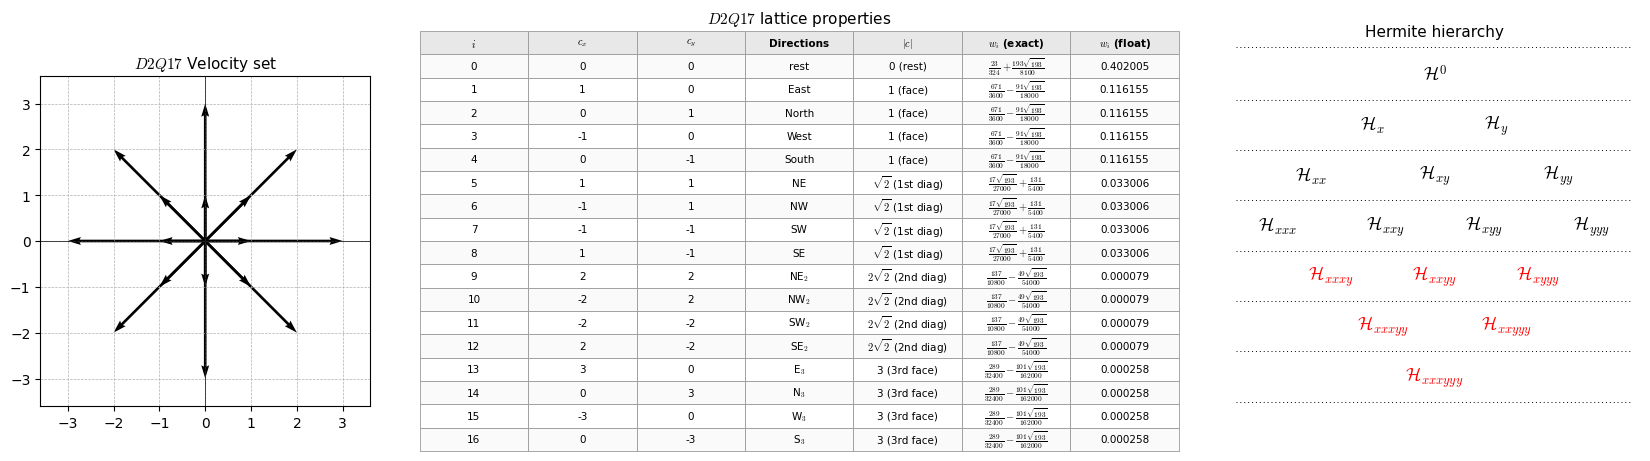

In [8]:
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display, Math
import numpy as np
import sympy as sp
from sympy import symbols, Function, Rational, sqrt, latex
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Global Matplotlib config: Computer Modern math font (matches LaTeX look)
matplotlib.rcParams['mathtext.fontset'] = 'cm'

#-------------------------------------------------Símbolos----------------------------------------------
omega, rho, w, theta, css = symbols('omega, \\rho, w, \\theta, c_{s}')
ux, uy = symbols('u^{*}_{x} u^{*}_{y}')
wi, cx, cy, cs = symbols('w_{i} c_{x} c_{y} c_{s}')

#-------------------------------------------------Funções----------------------------------------------
feq = Function('feq')(wi, cx, cy)

#-------------------------------------------------Variáveis----------------------------------------------
w0 = (575 + 193*sqrt(193))/8100
w1 = (3355 - 91*sqrt(193))/18000
w2 = (655 + 17*sqrt(193))/27000
w3 = (685 - 49*sqrt(193))/54000
w4 = (1445 - 101*sqrt(193))/162000

# cs = 1/sqrt((125 + 5*sqrt(193))/72)
as2 = (125 + 5*sqrt(193))/72
as2s = 1/(cs*cs)

wi = np.array([w0, w1, w1, w1, w1, w2, w2, w2, w2, w3, w3, w3, w3, w4, w4, w4, w4])
cx = np.array([0,  1,  0, -1,  0,  1, -1, -1,  1,  2, -2, -2,  2,  3,  0, -3,  0])
cy = np.array([0,  0,  1,  0, -1,  1,  1, -1, -1,  2,  2, -2, -2,  0,  3,  0, -3])

#-------------------------------------------------Calc.Func------------------------------------------------
feq = rho*wi*(1 + (as2*(cx*ux + cy*uy)) + (as2**2*(ux*cx + uy*cy)**2/2) - as2*(ux**2 + uy**2)/2
              + (as2**3*(ux*cx + uy*cy)**3/6) - (as2**2*(ux*cx + uy*cy)*(ux**2 + uy**2)/2))

#===========================BUILD TABLE DATA=====================================================
w_vals  = [sp.nsimplify(w) for w in wi]
w_float = [float(sp.N(w))    for w in wi]
cx_vals = [int(v) for v in cx]
cy_vals = [int(v) for v in cy]

# Explicit mapping for all 17 D2Q17 velocities (keyed by (cx, cy))
dir_map = {
    ( 0,  0): ('0 (rest)',                'rest'),
    ( 1,  0): ('1 (face)',                'East'),
    ( 0,  1): ('1 (face)',                'North'),
    (-1,  0): ('1 (face)',                'West'),
    ( 0, -1): ('1 (face)',                'South'),
    ( 1,  1): (r'$\sqrt{2}$ (1st diag)',  'NE'),
    (-1,  1): (r'$\sqrt{2}$ (1st diag)',  'NW'),
    (-1, -1): (r'$\sqrt{2}$ (1st diag)',  'SW'),
    ( 1, -1): (r'$\sqrt{2}$ (1st diag)',  'SE'),
    ( 2,  2): (r'$2\sqrt{2}$ (2nd diag)', 'NE$_2$'),
    (-2,  2): (r'$2\sqrt{2}$ (2nd diag)', 'NW$_2$'),
    (-2, -2): (r'$2\sqrt{2}$ (2nd diag)', 'SW$_2$'),
    ( 2, -2): (r'$2\sqrt{2}$ (2nd diag)', 'SE$_2$'),
    ( 3,  0): ('3 (3rd face)',            'E$_3$'),
    ( 0,  3): ('3 (3rd face)',            'N$_3$'),
    (-3,  0): ('3 (3rd face)',            'W$_3$'),
    ( 0, -3): ('3 (3rd face)',            'S$_3$'),
}

speed, direction = [], []
for i in range(17):
    s, d = dir_map[(cx_vals[i], cy_vals[i])]
    speed.append(s)
    direction.append(d)

headers = ['$i$', '$c_x$', '$c_y$', 'Directions', '$|c|$', '$w_i$ (exact)', '$w_i$ (float)']
cell_text = [[str(i), str(cx_vals[i]), str(cy_vals[i]), direction[i], speed[i],
              f'${sp.latex(w_vals[i])}$', f'{w_float[i]:.6f}'] for i in range(17)]

#==================FIGURE: LATTICE | TABLE | HERMITE HIERARCHY==============================================================
fig = plt.figure(figsize=(16.5, 4.4))
ax_lat = fig.add_axes([0.02, 0.05, 0.20, 0.88])   # left
ax_tab = fig.add_axes([0.25, 0.02, 0.46, 0.94])   # middle
ax_her = fig.add_axes([0.74, 0.05, 0.25, 0.88])   # right

ax_tab.axis('off')
ax_her.axis('off')
ax_her.set_xlim(0, 1)
ax_her.set_ylim(0, 1)

#-----------------------------------------------------------------------
#  LEFT: quiver lattice
#-----------------------------------------------------------------------
origin_x = np.zeros_like(cx)
origin_y = np.zeros_like(cy)
ax_lat.quiver(origin_x, origin_y, cx, cy, angles='xy', scale_units='xy', scale=1,
              color='black', width=0.008)

ax_lat.set_xlim(-3.6, 3.6)
ax_lat.set_ylim(-3.6, 3.6)
ax_lat.axhline(0, color='black', linewidth=0.5)
ax_lat.axvline(0, color='black', linewidth=0.5)
ax_lat.grid(True, linestyle='--', linewidth=0.5)
ax_lat.set_title("$D2Q17$ Velocity set", fontsize=11)
ax_lat.set_xticks(np.arange(-3, 4, 1))
ax_lat.set_yticks(np.arange(-3, 4, 1))
ax_lat.set_aspect('equal')

#-----------------------------------------------------------------------
#  MIDDLE: properties table
#-----------------------------------------------------------------------
table = ax_tab.table(cellText=cell_text, colLabels=headers, loc='center',
                     cellLoc='center', colLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(7.5)
table.scale(1.0, 1.4)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#999999')
    cell.set_linewidth(0.6)
    if r == 0:
        cell.set_facecolor('#e8e8e8')
        cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor('#fafafa' if r % 2 else 'white')

ax_tab.set_title("$D2Q17$ lattice properties", fontsize=11, pad=8)

#-----------------------------------------------------------------------
#  RIGHT: Hermite polynomial hierarchy
#-----------------------------------------------------------------------
ax_her.set_title("Hermite hierarchy", fontsize=11, pad=8)

levels = [
    (0.93, [(0.50, r'$\mathcal{H}^{0}$', 'black')]),
    (0.80, [(0.35, r'$\mathcal{H}_{x}$', 'black'), (0.65, r'$\mathcal{H}_{y}$', 'black')]),
    (0.67, [(0.20, r'$\mathcal{H}_{xx}$', 'black'), (0.50, r'$\mathcal{H}_{xy}$', 'black'),
            (0.80, r'$\mathcal{H}_{yy}$', 'black')]),
    (0.54, [(0.12, r'$\mathcal{H}_{xxx}$', 'black'), (0.38, r'$\mathcal{H}_{xxy}$', 'black'),
            (0.62, r'$\mathcal{H}_{xyy}$', 'black'), (0.88, r'$\mathcal{H}_{yyy}$', 'black')]),
    (0.41, [
        # (0.0, r'$\mathcal{H}_{xxxx}$', 'red'),
            (0.25, r'$\mathcal{H}_{xxxy}$', 'red'), (0.50, r'$\mathcal{H}_{xxyy}$', 'red'), (0.75, r'$\mathcal{H}_{xyyy}$', 'red'),
            # (1.0, r'$\mathcal{H}_{yyyy}$', 'red')
    ]),
    (0.28, [(0.375, r'$\mathcal{H}_{xxxyy}$', 'red'), (0.675, r'$\mathcal{H}_{xxyyy}$', 'red')]),
    (0.15, [(0.50, r'$\mathcal{H}_{xxxyyy}$', 'red')]),
]

sep_y = [1.00, 0.865, 0.735, 0.605, 0.475, 0.345, 0.215, 0.085]
for y in sep_y:
    ax_her.plot([0.02, 0.98], [y, y], color='black', linewidth=0.7,
                linestyle=(0, (1, 3)))

for y, items in levels:
    for x, txt, col in items:
        ax_her.text(x, y, txt, ha='center', va='center', fontsize=13, color=col)

plt.show()

#### Raw Moments

In [5]:
a0=sp.simplify(sum(feq))
ax=sp.simplify(sum(feq*cx))
ay=sp.simplify(sum(feq*cy))
axx=sp.expand(sp.collect(sp.expand(sum(feq*cx*cx)),rho).subs(sp.simplify(1/as2),cs*cs))
axy=sp.expand(sp.collect(sp.expand(sum(feq*cx*cy)),rho).subs(sp.simplify(1/as2),cs*cs))
ayy=sp.expand(sp.collect(sp.expand(sum(feq*cy*cy)),rho).subs(sp.simplify(1/as2),cs*cs))
axxx=sp.expand(sp.collect(sp.expand(sum(feq*cx*cx*cx)),rho*ux).subs(sp.simplify(3/as2),3*cs*cs))
axxy=sp.expand(sp.collect(sp.expand(sum(feq*cx*cx*cy)),rho*uy).subs(sp.simplify(1/as2),cs*cs))
axyy=sp.expand(sp.collect(sp.expand(sum(feq*cx*cy*cy)),rho*ux).subs(sp.simplify(1/as2),cs*cs))
ayyy=sp.expand(sp.collect(sp.expand(sum(feq*cy*cy*cy)),rho*uy).subs(sp.simplify(3/as2),3*cs*cs))
display(Math(r"\begin{gathered}"
    r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Moment}} =" + sp.latex(a0)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq}c_{i,x} }_{\textrm{x-First-Order Moment}} =" + sp.latex(ax)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq}c_{i,y} }_{\textrm{y-First-Order Moment}} =" + sp.latex(ay)
    +r"\end{gathered}"
))
display(Math(r"\begin{gathered}"
    r"\underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x} }_{\textrm{xx-Second-Order Moment}} =" + sp.latex(axx)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,y} }_{\textrm{xy-Second-Order Moment}} =" + sp.latex(axy)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,y}c_{i,y} }_{\textrm{yy-Second-Order Moment}} =" + sp.latex(ayy)
    +r"\end{gathered}"
))
display(Math(r"\begin{gathered}"
    r"\underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x}c_{i,x} }_{\textrm{xxx-Third-Order Moment}} =" + sp.latex(axxx)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x}c_{i,y} }_{\textrm{xxy-Third-Order Moment}} =" +  sp.latex(axxy)
    +r",\\[10pt]"
    +r"\underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,y}c_{i,y} }_{\textrm{xyy-Third-Order Moment}} =" +  sp.latex(axyy)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,y}c_{i,y}c_{i,y} }_{\textrm{yyy-Third-Order Moment}} =" + sp.latex(ayyy)
    +r"\end{gathered}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Hermite Moments

In [6]:
aH0=sp.simplify(sum(feq))
aHx=sp.simplify(sum(feq*cx))
aHy=sp.simplify(sum(feq*cy))
aHxx=sp.collect(sp.expand(sum(feq*(cx*cx-cs**2))),rho).subs(sp.simplify(1/as2),cs*cs)
aHxy=sp.simplify(sum(feq*(cx*cy)))
aHyy=sp.collect(sp.expand(sum(feq*(cy*cy-cs**2))),rho).subs(sp.simplify(1/as2),cs*cs)
aHxxx=sp.collect(sp.expand(sum(feq*(cx*cx-3*cs**2)*cx)),rho*ux).subs(sp.simplify(3/as2),3*cs*cs)
aHxxy=sp.collect(sp.expand(sum(feq*(cx*cx-cs**2)*cy)),rho*uy).subs(sp.simplify(1/as2),cs*cs)
aHxyy=sp.collect(sp.expand(sum(feq*(cy*cy-cs**2)*cx)),rho*ux).subs(sp.simplify(1/as2),1*cs*cs)
aHyyy=sp.collect(sp.expand(sum(feq*(cy*cy-3*cs**2)*cy)),rho*uy).subs(sp.simplify(3/as2),3*cs*cs)
display(Math(r"\begin{gathered}"
    r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Hermite Moment}} =" +  sp.latex(aH0) 
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq}c_{i,x} }_{\textrm{x-First-Order Hermite Moment}} =" +  sp.latex(aHx)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq}c_{i,y} }_{\textrm{y-First-Order Hermite Moment}} =" +  sp.latex(aHy)
    +r"\end{gathered}"
))
display(Math(r"\begin{gathered}"
    r"\underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x} }_{\textrm{xx-Second-Order Moment}} =" + sp.latex(aHxx)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,y} }_{\textrm{xy-Second-Order Moment}} =" + sp.latex(aHxy)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,y}c_{i,y} }_{\textrm{yy-Second-Order Moment}} =" + sp.latex(aHyy)
    +r"\end{gathered}"
))
display(Math(r"\begin{gathered}"
    r"\underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x}c_{i,x} }_{\textrm{xxx-Third-Order Moment}} =" + sp.latex(aHxxx)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x}c_{i,y} }_{\textrm{xxy-Third-Order Moment}} =" +  sp.latex(aHxxy)
    +r",\\[10pt]"
    +r"\underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,y}c_{i,y} }_{\textrm{xyy-Third-Order Moment}} =" +  sp.latex(aHxyy)
    +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,y}c_{i,y}c_{i,y} }_{\textrm{yyy-Third-Order Moment}} =" + sp.latex(aHyyy)
    +r"\end{gathered}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Doing the Chapman-Enskog analysis for the lattice D2V17, we obtain the same Eqs. {eq}`ns-e-Kn1-B0-all`, {eq}`ns-e-Kn2-B0-all`, {eq}`ns-e-Kn3-B0-all`, {eq}`ns-e-Kn1-B1-all`, {eq}`ns-e-Kn2-B1-all`, and {eq}`ns-e-Kn3-B1-all`. However, the calculation of the second-order moment of non-equilibrium $ m^{(1)}_{\alpha\beta}$ will change due to the D2V17 be able to correctly recover the third-order moments:

::::{only} html
$$
\begin{array}{ll}
(Kn^{(1)}):& \displaystyle\sum_{i}\left( \partial_{t}^{(0)} + c_{i,\gamma}\partial_{\gamma} \right)f_{i}^{(0)}c_{i,\alpha}c_{i,\beta}= - \displaystyle\sum_{i}\left(\displaystyle\frac{ f_{i}^{(1)} }{ \tau } c_{i,\alpha}c_{i,\beta} \right),\\
(Kn^{(1)}):& \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} + \rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho \left(u_{\alpha}\delta_{\beta\gamma} + u_{\beta}\delta_{\alpha\gamma} + u_{\gamma}\delta_{\alpha\beta} \right) \right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau}, \\
(Kn^{(1)}):& \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} + \rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho \left(u_{\alpha}\delta_{\beta\gamma} + u_{\beta}\delta_{\alpha\gamma} + u_{\gamma}\delta_{\alpha\beta} \right) \right) + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& \partial_{t}^{(0)}  \left(\rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} \right) +  c_{s}^{2} \left(\partial_{\gamma} (\rho u_{\alpha})\delta_{\beta\gamma} + \partial_{\gamma}(\rho u_{\beta} )\delta_{\alpha\gamma} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho u_{\gamma}\delta_{\alpha\beta} \right) + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& c_{s}^{2} \partial_{t}^{(0)}  \left(\rho\right) \delta_{\alpha\beta} + \rho u_{\alpha} \partial_{t}^{(0)} \left(u_{\beta} \right) + u_{\beta}\partial_{t}^{(0)}  \left(\rho u_{\alpha}\right) +  c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) + c_{s}^{2} \partial_{\gamma} \left(\rho u_{\gamma} \right) \delta_{\alpha\beta} + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& -\textcolor{red}{c_{s}^{2} \partial_{\gamma} \left( \rho u_{\gamma} \right)\delta_{\alpha\beta}} + 
            \rho u_{\alpha} \partial_{t}^{(0)} \left(u_{\beta} \right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) + 
            \textcolor{red}{c_{s}^{2} \partial_{\gamma} \left(\rho u_{\gamma} \right) \delta_{\alpha\beta}} + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( -u_{\beta}\partial_{t}^{(0)} \rho  - \partial_{\gamma} \left(\rho u_{\beta}u_{\gamma} + \rho c_{s}^{2}\delta_{\beta\gamma} \right)\right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) 
            + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( u_{\beta}\partial_{\gamma} (\rho u_{\gamma})  - \partial_{\gamma} \left(\rho u_{\beta}u_{\gamma} + \rho c_{s}^{2}\delta_{\beta\gamma} \right)\right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) 
            + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( -\rho u_{\gamma}\partial_{\gamma} u_{\beta}  - c_{s}^{2}\partial_{\beta} \rho \right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) 
            + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&   -\rho u_{\alpha}u_{\gamma}\partial_{\gamma} u_{\beta}  - c_{s}^{2}u_{\alpha}\partial_{\beta} \rho - 
            u_{\beta} \partial_{\gamma}\rho u_{\alpha}u_{\gamma} - u_{\beta}c_{s}^{2} \partial_{\alpha}\rho  +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) 
            + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&   \textcolor{red}{-\partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma})} 
            - c_{s}^{2} (u_{\alpha}\partial_{\beta} \rho + u_{\beta} \partial_{\alpha}\rho)  +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) 
            \textcolor{red}{+ \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right)} = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&  c_{s}^{2} \rho\left(\partial_{\beta} u_{\alpha} + \partial_{\alpha} u_{\beta} \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},  \qquad \rightarrow \qquad  m^{(1)}_{\alpha\beta} = -c_{s}^{2} \tau \rho\left(\partial_{\beta} u_{\alpha} + \partial_{\alpha} u_{\beta} \right)
\end{array}
$$(ns-e-Kn1-B2-all-D2V17)
::::

::::{only} latex
$$
\scriptsize
\begin{array}{ll}
(Kn^{(1)}):& \displaystyle\sum_{i}\left( \partial_{t}^{(0)} + c_{i,\gamma}\partial_{\gamma} \right)f_{i}^{(0)}c_{i,\alpha}c_{i,\beta}= - \displaystyle\sum_{i}\left(\displaystyle\frac{ f_{i}^{(1)} }{ \tau } c_{i,\alpha}c_{i,\beta} \right),\\
(Kn^{(1)}):& \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} + \rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho \left(u_{\alpha}\delta_{\beta\gamma} + u_{\beta}\delta_{\alpha\gamma} + u_{\gamma}\delta_{\alpha\beta} \right) \right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau}, \\
(Kn^{(1)}):& \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} + \rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho \left(u_{\alpha}\delta_{\beta\gamma} + u_{\beta}\delta_{\alpha\gamma} + u_{\gamma}\delta_{\alpha\beta} \right) \right) + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& \partial_{t}^{(0)}  \left(\rho c_{s}^{2}\delta_{\alpha\beta} \right) + \partial_{t}^{(0)}  \left(\rho u_{\alpha}u_{\beta} \right) +  c_{s}^{2} \left(\partial_{\gamma} (\rho u_{\alpha})\delta_{\beta\gamma} + \partial_{\gamma}(\rho u_{\beta} )\delta_{\alpha\gamma} \right) + \partial_{\gamma} \left(c_{s}^{2}\rho u_{\gamma}\delta_{\alpha\beta} \right) + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& c_{s}^{2} \partial_{t}^{(0)}  \left(\rho\right) \delta_{\alpha\beta} + \rho u_{\alpha} \partial_{t}^{(0)} \left(u_{\beta} \right) + u_{\beta}\partial_{t}^{(0)}  \left(\rho u_{\alpha}\right) +  c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) + c_{s}^{2} \partial_{\gamma} \left(\rho u_{\gamma} \right) \delta_{\alpha\beta} + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& -\textcolor{red}{c_{s}^{2} \partial_{\gamma} \left( \rho u_{\gamma} \right)\delta_{\alpha\beta}} + 
            \rho u_{\alpha} \partial_{t}^{(0)} \left(u_{\beta} \right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) + 
            \textcolor{red}{c_{s}^{2} \partial_{\gamma} \left(\rho u_{\gamma} \right) \delta_{\alpha\beta}} + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( -u_{\beta}\partial_{t}^{(0)} \rho  - \partial_{\gamma} \left(\rho u_{\beta}u_{\gamma} + \rho c_{s}^{2}\delta_{\beta\gamma} \right)\right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) 
            + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( u_{\beta}\partial_{\gamma} (\rho u_{\gamma})  - \partial_{\gamma} \left(\rho u_{\beta}u_{\gamma} + \rho c_{s}^{2}\delta_{\beta\gamma} \right)\right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) 
            + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):& u_{\alpha} \left( -\rho u_{\gamma}\partial_{\gamma} u_{\beta}  - c_{s}^{2}\partial_{\beta} \rho \right) - 
            u_{\beta} \partial_{\gamma} \left(\rho u_{\alpha}u_{\gamma} + \rho c_{s}^{2}\delta_{\alpha\gamma} \right) +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) 
            + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&   -\rho u_{\alpha}u_{\gamma}\partial_{\gamma} u_{\beta}  - c_{s}^{2}u_{\alpha}\partial_{\beta} \rho - 
            u_{\beta} \partial_{\gamma}\rho u_{\alpha}u_{\gamma} - u_{\beta}c_{s}^{2} \partial_{\alpha}\rho  +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) 
            + \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&   \textcolor{red}{-\partial_{\gamma} (\rho u_{\alpha}u_{\beta}u_{\gamma})} 
            - c_{s}^{2} (u_{\alpha}\partial_{\beta} \rho + u_{\beta} \partial_{\alpha}\rho)  +  
            c_{s}^{2} \left(\partial_{\beta} (\rho u_{\alpha}) + \partial_{\alpha} (\rho u_{\beta}) \right) 
            \textcolor{red}{+ \partial_{\gamma}\left( u_{\alpha} u_{\beta} u_{\gamma}\right)} = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},\\
(Kn^{(1)}):&  c_{s}^{2} \rho\left(\partial_{\beta} u_{\alpha} + \partial_{\alpha} u_{\beta} \right) = 
            - \displaystyle\frac{m^{(1)}_{\alpha\beta}}{\tau},  \qquad \rightarrow \qquad  m^{(1)}_{\alpha\beta} = -c_{s}^{2} \tau \rho\left(\partial_{\beta} u_{\alpha} + \partial_{\alpha} u_{\beta} \right)
\end{array}
$$(ns-e-Kn1-B2-all-D2V17)
::::

Repeting the process for momentum balance, we sum the Eqs. {eq}`ns-e-Kn1-B1-all`, {eq}`ns-e-Kn2-B1-all`, {eq}`ns-e-Kn3-B1-all`, and {eq}`ns-e-Kn1-B2-all-D2V17`:

::::{only} html
$$
\begin{array}{l}
\partial_t \rho u_{\alpha} + \partial_{\beta}\left(\rho u_{\alpha}\rho u_{\beta}\right) = \partial_{\beta}\left( -\rho c_{s}^{2} \delta_{\alpha\beta} + \left(\tau-\displaystyle\frac{1}{2}\right) \rho c_{s}^{2}\left(\partial_{\alpha}u_{\beta}+\partial_{\beta}u_{\alpha}\right) \right) \underbrace{- \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(0)}\partial_{\gamma} m^{(1)}_{\alpha\gamma} + \partial_{\beta}\partial_{\gamma} m^{(1)}_{\alpha\beta\gamma} \right) + ... + \mathcal{O}(Kn^{(> 3)}) }_{\textrm{Numerical Errors}} =0,\\
\partial_t \rho u_{\alpha} + \partial_{\beta}\left(\rho u_{\alpha}\rho u_{\beta}\right) = \partial_{\beta}\left( -p \delta_{\alpha\beta} + \mu\left(\partial_{\alpha}u_{\beta}+\partial_{\beta}u_{\alpha}\right) \right) \underbrace{- \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(0)}\partial_{\gamma} m^{(1)}_{\alpha\gamma} + \partial_{\beta}\partial_{\gamma} m^{(1)}_{\alpha\beta\gamma} \right) + ... + \mathcal{O}(Kn^{(> 3)}) }_{\textrm{Numerical Errors}} =0,\\
\end{array}
$$
::::

::::{only} latex
$$
\begin{array}{l}
\partial_t \rho u_{\alpha} + \partial_{\beta}\left(\rho u_{\alpha}\rho u_{\beta}\right) =  \partial_{\beta}\left( -\rho c_{s}^{2} \delta_{\alpha\beta} + \left(\tau-\displaystyle\frac{1}{2}\right) \rho c_{s}^{2}\left(\partial_{\alpha}u_{\beta}+\partial_{\beta}u_{\alpha}\right) \right) \\
 \underbrace{- \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(0)}\partial_{\gamma} m^{(1)}_{\alpha\gamma} + \partial_{\beta}\partial_{\gamma} m^{(1)}_{\alpha\beta\gamma} \right) + ... + \mathcal{O}(Kn^{(> 3)}) }_{\textrm{Numerical Errors}} =0,\\
\partial_t \rho u_{\alpha} + \partial_{\beta}\left(\rho u_{\alpha}\rho u_{\beta}\right) =  \partial_{\beta}\left( -p \delta_{\alpha\beta} + \mu\left(\partial_{\alpha}u_{\beta}+\partial_{\beta}u_{\alpha}\right) \right) \\
\underbrace{- \displaystyle\left(1 - \frac{1}{6\tau} - \tau\right) \left( \partial_{t}^{(0)}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(0)}\partial_{\gamma} m^{(1)}_{\alpha\gamma} + \partial_{\beta}\partial_{\gamma} m^{(1)}_{\alpha\beta\gamma} \right) + ... + \mathcal{O}(Kn^{(> 3)}) }_{\textrm{Numerical Errors}} =0,\\
\end{array}
$$
::::

where $\mu=\rho c_{s}^{2}(\tau-1/2)$.

## Tutorials

::::{only} html
* [Shear-Wave D2Q9](Gallilean-Invariance/D2Q9/Shear-Wave-D2Q9.ipynb)
::::